# Figure S9. Taxonomy consistency + UHVDB taxonomy benchmark

In [41]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [42]:
### filter UHGV metadata to HQ viruses
hq_votus = (
    pl.read_csv('../figure_s9/votus_metadata_extended.tsv', separator='\t', ignore_errors=True, null_values=['NULL'], columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'uhgv_taxonomy', 'class_name', 'order_name', 'family_name', 'genus_name', 'host_lineage_gtdb_r207', 'crispr_host_lineage_gtdb_r207', 'kmers_host_lineage_gtdb_r207', 'host_prediction_method', 'lifestyle', 'lifestyle_evidence'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .rename({'class_name':'Class', 'order_name':'Order', 'family_name':'Family', 'genus_name':'Genus'})
        .with_columns([
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vOTU-')).then(pl.col('uhgv_taxonomy').str.split(';vOTU-').list[-1]).otherwise(pl.lit(None)).alias('virus_species'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBGEN-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBGEN-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subgenus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vGENUS-')).then(pl.col('uhgv_taxonomy').str.split(';vGENUS-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_genus'),
            pl.when(pl.col('uhgv_taxonomy').str.contains(';vSUBFAM-')).then(pl.col('uhgv_taxonomy').str.split(';vSUBFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_subfamily'),
            pl.when(pl.col('uhgv_taxonomy').str.contains('vFAM-')).then(pl.col('uhgv_taxonomy').str.split('vFAM-').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('virus_family'),
        ])
)

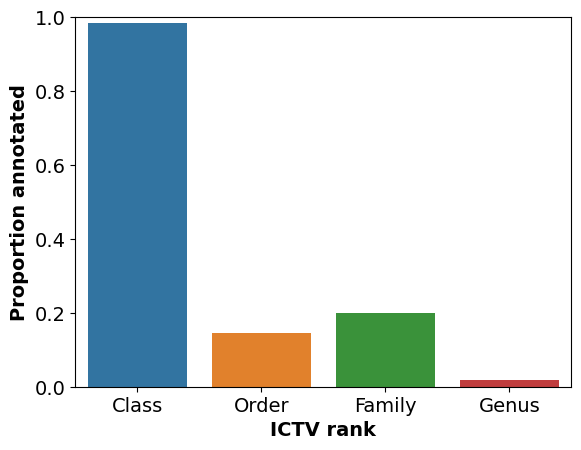

In [43]:
### ICTV annotation rates for UHGV sequences
ictv_prop = []
ictv_rank = []

for ictv_level in ['Class', 'Order', 'Family', 'Genus']:
    ictv_prop.append(
       hq_votus.filter(pl.col(ictv_level) != 'NULL').height / hq_votus.height
    )
    ictv_rank.append(ictv_level)

plot_df = pl.DataFrame({
    'ictv_proportion': ictv_prop,
    'ICTV rank': ictv_rank
})

# create boxplot of ictv agreement
sns.barplot(data=plot_df, y='ictv_proportion', x='ICTV rank', hue='ICTV rank')
plt.ylim(0,1)
plt.ylabel('Proportion annotated', fontdict={'fontweight': 'bold'})
plt.xlabel('ICTV rank', fontdict={'fontweight': 'bold'})
plt.show()

### Taxonomy consistency across releases (compare original UHGV taxonomy from taxonomy from geNomad 1.9)

In [44]:
### Run updated genomad on UHGV HQ plus sequences
%%bash
# seqkit split2 \
#     votus_hq_plus.fna.gz \
#     --by-size 10000 \
#     --out-dir uhgv_votu_hq_plus_split/

# sbatch genoamd.sh

UsageError: Line magic function `%%bash` not found.


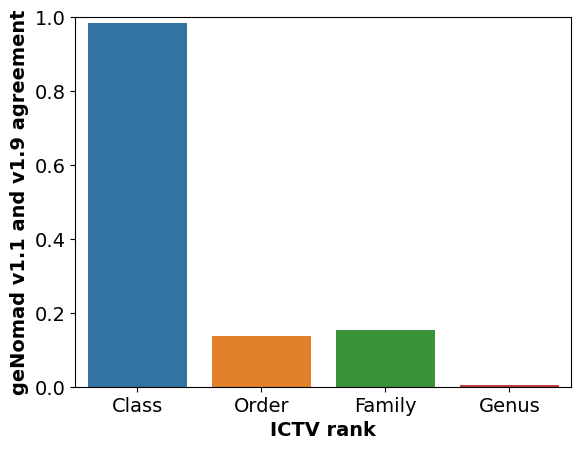

In [45]:
# read in genomad results
genomad_results_lst = []

for f in sorted(glob.glob('genomad_results/*/*/*_taxonomy.tsv')):
    df = pl.read_csv(f, separator='\t')
    genomad_results_lst.append(df)

genomad_results_df = pl.concat(genomad_results_lst)

# identify taxa in genomad results
genomad_results_df = (
    genomad_results_df
        .with_columns([
            pl.col('lineage').str.split(';').list[0].alias('domain'),
            pl.col('lineage').str.split(';').list[1].alias('realm'),
            pl.col('lineage').str.split(';').list[3].alias('kingdom'),
            pl.col('lineage').str.split(';').list[5].alias('phylum'),
            pl.col('lineage').str.split(';').list[7].alias('class'),
            pl.col('lineage').str.split(';').list[9].alias('order'),
            pl.col('lineage').str.split(';').list[11].alias('family'),
            pl.col('lineage').str.split(';').list[13].alias('genus')
        ])
)

# join 1.1 results to 1.9
merged = (
    genomad_results_df
    .join(hq_votus, left_on='seq_name', right_on='uhgv_genome', how='inner')
        .with_columns([
            pl.col('Class').str.replace('NULL', ''),
            pl.col('Order').str.replace('NULL', ''),
            pl.col('Family').str.replace('NULL', ''),
            pl.col('Genus').str.replace('NULL', '')
        ])
)

ictv_prop = []
ictv_rank = []

for ictv_level in ['Class', 'Order', 'Family', 'Genus']:
    ictv_prop.append(
       merged.filter(pl.col(ictv_level) == pl.col(ictv_level.lower())).height / merged.height
    )
    ictv_rank.append(ictv_level)

plot_df = pl.DataFrame({
    'ictv_proportion': ictv_prop,
    'ICTV rank': ictv_rank
})

# create boxplot of ictv agreement
sns.barplot(data=plot_df, y='ictv_proportion', x='ICTV rank', hue='ICTV rank')
plt.ylim(0,1)
plt.ylabel('geNomad v1.1 and v1.9 agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('ICTV rank', fontdict={'fontweight': 'bold'})
plt.show()

In [ ]:
%%bash
# ### ICTV consistency across releases
# wget https://ictv.global/sites/default/files/VMR/VMR_21-221122_MSL37.xlsx
# wget https://ictv.global/sites/default/files/VMR/VMR_MSL40.v2.20251013.xlsx

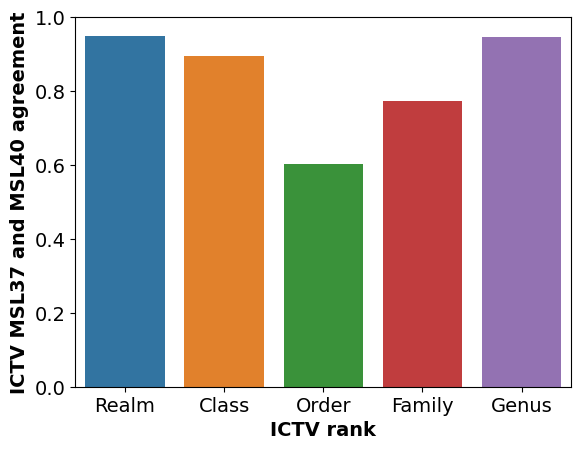

In [46]:
### Load both MSLs
msl37 = pl.read_excel('VMR_21-221122_MSL37.xlsx', sheet_name='VMRb37', columns=['Virus GENBANK accession', 'Genus', 'Family', 'Order', 'Class', 'Realm'])
msl40 = pl.read_excel('VMR_MSL40.v2.20251013.xlsx', sheet_name='VMR MSL40', columns=['Virus GENBANK accession', 'Genus', 'Family', 'Order', 'Class', 'Realm'])

# join on accessions
merged_msl = (
    msl37
        .join(msl40, on='Virus GENBANK accession', how='inner', suffix='_v40')
)

# calculate agreement at each rank
ictv_prop = []
ictv_rank = []

for ictv_level in ['Realm', 'Class', 'Order', 'Family', 'Genus']:
    ictv_prop.append(
       merged_msl.filter(pl.col(ictv_level) == pl.col(f'{ictv_level}_v40')).height / merged_msl.height
    )
    ictv_rank.append(ictv_level)

plot_df = pl.DataFrame({
    'ictv_proportion': ictv_prop,
    'ICTV rank': ictv_rank
})
# create boxplot of ictv agreement
sns.barplot(data=plot_df, y='ictv_proportion', x='ICTV rank', hue='ICTV rank')
plt.ylim(0,1)
plt.ylabel('ICTV MSL37 and MSL40 agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('ICTV rank', fontdict={'fontweight': 'bold'})
plt.show()

### Comparing UHVDB to UHGV taxonomic assignments

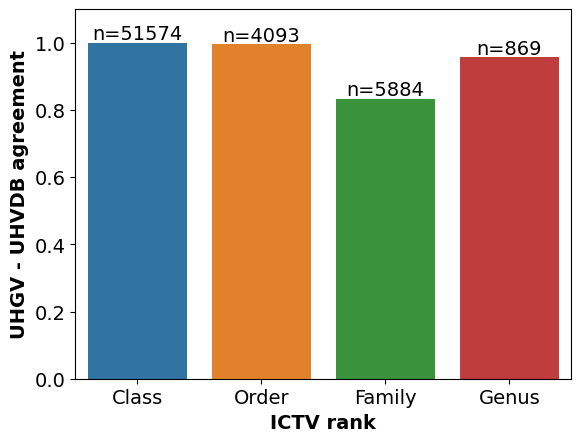

In [ ]:
### Load UHVDB results
uhvdb_taxonomy = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11/uhvdb/taxonomy/uhvdb_taxonomy/normscore.taxonomy.tsv.gz', separator='\t', ignore_errors=True)   
)

# load mapping file
mapping = (
    pl.read_csv('../figure_1/uhgv_hq_hc_results/2026-03-11_outputs/rename/hq_hc_viruses/hq_hc_viruses.id_mapping.tsv.gz', separator='\t', ignore_errors=True, has_header=False)
    .with_columns([
        pl.col('column_1').str.replace(r'\|provirus.*', '')
    ])
)

# joing uhgv and uhvdb results
uhgv_uhvdb_joined = (
    uhvdb_taxonomy
        .join(mapping, left_on='seq_name', right_on='column_2', how='inner')
        .join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='inner', suffix='_uhgv')
)

# calculate agreement at each rank
agreement_prop = []
agreement_rank = []
agreement_count = []

for rank in ['Class', 'Order', 'Family', 'Genus']:
    comparable = uhgv_uhvdb_joined.filter(pl.col(rank).is_not_null() & pl.col(f'{rank}_uhgv').is_not_null())
    comparable_n = comparable.height
    matched_n = comparable.filter(pl.col(rank) == pl.col(f'{rank}_uhgv')).height

    agreement_prop.append(matched_n / comparable_n if comparable_n > 0 else 0)
    agreement_rank.append(rank)
    agreement_count.append(comparable_n)

plot_df = pl.DataFrame({
    'agreement': agreement_prop,
    'ICTV rank': agreement_rank,
    'count': agreement_count
})

# create a boxplot of agreement between UHGV and UHVDB classifications
sns.barplot(data=plot_df, y='agreement', x='ICTV rank', hue='ICTV rank')
plt.ylim(0,1.1)
plt.ylabel('UHGV - UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.xlabel('ICTV rank', fontdict={'fontweight': 'bold'})
# put the count above the bars
for i, row in enumerate(plot_df.iter_rows(named=True)):
    plt.text(i, row['agreement'] + 0.01, f"n={row['count']}", ha='center')

plt.show()


In [55]:
uhvdb_taxonomy.unique('seq_name')

taxonomy,seq_name,Class,ref,normscore,Species,Genus,Family,Order
str,str,str,str,f64,str,str,str,str
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-143800""","""Caudoviricetes""",null,null,null,null,null,null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-105905""","""Caudoviricetes""","""Totsukavirus_waseda--OP074812.…",11.27,"""Totsukavirus waseda""","""Totsukavirus""","""Toyamaviridae""",null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-165369""","""Caudoviricetes""","""Honmavirus_pging00G--BK068093.…",12.67,"""Honmavirus pging00G""","""Honmavirus""","""Alisviridae""",null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-157733""","""Caudoviricetes""","""Popoffvirus_pv56--JQ177063.1""",5.78,"""Popoffvirus pv56""","""Popoffvirus""",null,null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-70589""","""Caudoviricetes""",null,null,null,null,null,null
…,…,…,…,…,…,…,…,…
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-65746""","""Caudoviricetes""","""Cequinquevirus_c5--EU340421.2""",6.1,"""Cequinquevirus c5""","""Cequinquevirus""",null,null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-49227""","""Caudoviricetes""",null,null,null,null,null,null
"""Viruses;Duplodnaviria;Heunggon…","""UHVDB-59696""","""Caudoviricetes""","""Malkevirus_ARI02853--KT337347.…",11.23,"""Malkevirus ARI02853""","""Malkevirus""",null,null


In [51]:
uhgv_uhvdb_joined.height

52266

In [52]:
hq_votus.height

57514